## 1. Import Libraries

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 20)

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 2. Load Raw Data

In [ ]:
RAW_FILE = 'LD2011_2014 - Copy.txt'

print(f'Loading {RAW_FILE}... (this may take a minute due to file size)')

df = pd.read_csv(
    RAW_FILE,
    sep=';',
    decimal=',',
    index_col=0,
    parse_dates=True
)

print(f'Data loaded successfully!')
print(f'Shape: {df.shape}')

Loading LD2011_2014 - Copy.txt... (this may take a minute due to file size)
Data loaded successfully!
Shape: (140256, 370)


## 3. Initial Data Exploration

In [33]:
# First few rows
print('=== First 5 Rows ===')
df.head()

=== First 5 Rows ===


,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
2011-01-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:45:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [34]:
# Last few rows
print('=== Last 5 Rows ===')
df.tail()

=== Last 5 Rows ===


,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
2014-12-31 23:00:00,2.538071,22.048364,1.737619,150.406504,85.365854,303.571429,11.305822,282.828283,68.181818,72.043011,...,276.945039,28200.0,1616.033755,1363.636364,29.986962,5.851375,697.102722,176.961603,651.026393,7621.621622
2014-12-31 23:15:00,2.538071,21.337127,1.737619,166.666667,81.707317,324.404762,11.305822,252.525253,64.685315,72.043011,...,279.800143,28300.0,1569.620253,1340.909091,29.986962,9.947338,671.641791,168.614357,669.354839,6702.702703
2014-12-31 23:30:00,2.538071,20.625889,1.737619,162.601626,82.926829,318.452381,10.175240,242.424242,61.188811,74.193548,...,284.796574,27800.0,1556.962025,1318.181818,27.379400,9.362200,670.763828,153.589316,670.087977,6864.864865
2014-12-31 23:45:00,1.269036,21.337127,1.737619,166.666667,85.365854,285.714286,10.175240,225.589226,64.685315,72.043011,...,246.252677,28000.0,1443.037975,909.090909,26.075619,4.095963,664.618086,146.911519,646.627566,6540.540541
2015-01-01 00:00:00,2.538071,19.914651,1.737619,178.861789,84.146341,279.761905,10.175240,249.158249,62.937063,69.892473,...,188.436831,27800.0,1409.282700,954.545455,27.379400,4.095963,628.621598,131.886477,673.020528,7135.135135


In [35]:
# Data types and info
print('=== Data Types ===')
print(df.dtypes.value_counts())
print(f'\nIndex dtype: {df.index.dtype}')
print(f'Index name: {df.index.name}')
print(f'Date range: {df.index.min()} to {df.index.max()}')
print(f'Total duration: {df.index.max() - df.index.min()}')

=== Data Types ===
float64    370
Name: count, dtype: int64

Index dtype: datetime64[ns]
Index name: None
Date range: 2011-01-01 00:15:00 to 2015-01-01 00:00:00
Total duration: 1460 days 23:45:00


In [36]:
# Basic statistics
df.describe()

,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
count,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,...,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000
mean,3.970785,20.768480,2.918308,82.184490,37.240309,141.227385,4.521338,191.401476,39.975354,42.205152,...,218.213701,37607.987537,1887.427366,2940.031734,65.413150,9.269709,424.262904,94.704717,625.251734,8722.355145
std,5.983965,13.272415,11.014456,58.248392,26.461327,98.439984,6.485684,121.981187,29.814595,33.401251,...,204.833532,38691.954832,1801.486488,2732.251967,65.007818,10.016782,274.337122,80.297301,380.656042,9195.155777
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.844950,0.000000,36.585366,15.853659,71.428571,0.565291,111.111111,13.986014,9.677419,...,5.710207,0.000000,0.000000,0.000000,13.037810,0.000000,0.000000,30.050083,83.944282,0.000000
50%,1.269036,24.893314,1.737619,87.398374,39.024390,157.738095,2.826456,222.222222,40.209790,40.860215,...,131.334761,24100.000000,1050.632911,2136.363636,31.290743,7.021650,525.899912,76.794658,758.064516,0.000000
75%,2.538071,29.871977,1.737619,115.853659,54.878049,205.357143,4.522329,279.461279,57.692308,61.290323,...,403.283369,54800.000000,3312.236287,5363.636364,108.213820,11.702750,627.743635,151.919866,875.366569,17783.783784
max,48.223350,115.220484,151.172893,321.138211,150.000000,535.714286,44.657999,552.188552,157.342657,198.924731,...,852.962170,192800.000000,7751.054852,12386.363636,335.071708,60.269163,1138.718174,362.270451,1549.120235,30918.918919


## 4. Data Quality Checks

In [37]:
# 4.1 Check for missing values
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_pct
})

print(f'Total NaN values: {df.isnull().sum().sum()}')
print(f'Columns with missing values: {(missing_count > 0).sum()} / {len(df.columns)}')

# Show columns with missing values (if any)
if (missing_count > 0).any():
    print('\nColumns with missing values:')
    display(missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing %', ascending=False))
else:
    print('\nNo missing values found!')

Total NaN values: 0
Columns with missing values: 0 / 370

No missing values found!


In [38]:
# 4.2 Check for duplicate timestamps
duplicate_timestamps = df.index.duplicated().sum()
print(f'Duplicate timestamps: {duplicate_timestamps}')

# Check time frequency consistency
time_diffs = pd.Series(df.index).diff().dropna()
print(f'\nTime interval statistics:')
print(f'  Most common interval: {time_diffs.mode()[0]}')
print(f'  Min interval: {time_diffs.min()}')
print(f'  Max interval: {time_diffs.max()}')

# Check for gaps in timeline
expected_freq = pd.Timedelta('15min')
gaps = time_diffs[time_diffs != expected_freq]
print(f'  Irregular intervals: {len(gaps)}')
if len(gaps) > 0:
    print(f'  Gap details (first 10):')
    for i, (idx, gap) in enumerate(gaps.items()):
        if i >= 10:
            print(f'    ... and {len(gaps) - 10} more')
            break
        print(f'    At index {idx}: gap = {gap}')

Duplicate timestamps: 0

Time interval statistics:
  Most common interval: 0 days 00:15:00
  Min interval: 0 days 00:15:00
  Max interval: 0 days 00:15:00
  Irregular intervals: 0


=== Zero-Value Analysis ===
Meters that are 100% zero: 0
Meters with >90% zeros: 0
Meters with >50% zeros: 43
Meters with <10% zeros: 157


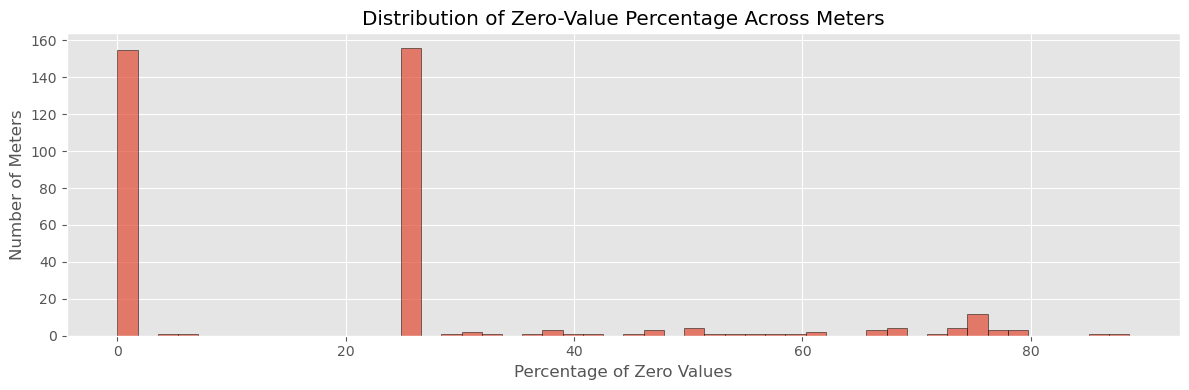

In [39]:
# 4.3 Check for zero-consumption meters
# Some meters may have been inactive for portions of the dataset

zero_pct = (df == 0).sum() / len(df) * 100

print('=== Zero-Value Analysis ===')
print(f'Meters that are 100% zero: {(zero_pct == 100).sum()}')
print(f'Meters with >90% zeros: {(zero_pct > 90).sum()}')
print(f'Meters with >50% zeros: {(zero_pct > 50).sum()}')
print(f'Meters with <10% zeros: {(zero_pct < 10).sum()}')

# Plot distribution of zero percentages
fig, ax = plt.subplots(figsize=(12, 4))
zero_pct.hist(bins=50, ax=ax, edgecolor='black', alpha=0.7)
ax.set_xlabel('Percentage of Zero Values')
ax.set_ylabel('Number of Meters')
ax.set_title('Distribution of Zero-Value Percentage Across Meters')
plt.tight_layout()
plt.show()

In [40]:
# 4.4 Check for negative values
negative_count = (df < 0).sum()
meters_with_negatives = negative_count[negative_count > 0]

print(f'Meters with negative values: {len(meters_with_negatives)}')
if len(meters_with_negatives) > 0:
    print('\nNegative value details:')
    for col in meters_with_negatives.index:
        neg_vals = df[col][df[col] < 0]
        print(f'  {col}: {len(neg_vals)} negative values, min = {neg_vals.min():.4f}')

Meters with negative values: 0


## 5. Data Cleaning & Preprocessing

In [41]:
# 5.1 Rename the index
df.index.name = 'datetime'
print(f'Index renamed to: {df.index.name}')

# 5.2 Ensure index is DatetimeIndex and sorted
df.index = pd.to_datetime(df.index)
df = df.sort_index()
print(f'Index sorted: {df.index.is_monotonic_increasing}')

Index renamed to: datetime
Index sorted: True


In [42]:
# 5.3 Handle missing values (if any)
if df.isnull().sum().sum() > 0:
    print('Filling missing values with forward fill, then backward fill...')
    df = df.ffill().bfill()
    print(f'Remaining NaN values: {df.isnull().sum().sum()}')
else:
    print('No missing values to handle.')

No missing values to handle.


In [43]:
# 5.4 Identify and remove completely inactive meters (100% zero)
zero_pct = (df == 0).sum() / len(df) * 100
inactive_meters = zero_pct[zero_pct == 100].index.tolist()

print(f'Completely inactive meters (100% zero): {len(inactive_meters)}')
if inactive_meters:
    print(f'  Meters: {inactive_meters}')

# Create cleaned version without fully inactive meters
df_clean = df.drop(columns=inactive_meters)
print(f'\nShape after removing inactive meters: {df_clean.shape}')

Completely inactive meters (100% zero): 0

Shape after removing inactive meters: (140256, 370)


In [44]:
# 5.5 Handle negative values — clip to zero
neg_count_before = (df_clean < 0).sum().sum()
if neg_count_before > 0:
    print(f'Clipping {neg_count_before} negative values to 0...')
    df_clean = df_clean.clip(lower=0)
    print('Done.')
else:
    print('No negative values to clip.')

No negative values to clip.


## 6. Feature Engineering

In [45]:
# 6.1 Add time-based features
df_features = df_clean.copy()

df_features['hour'] = df_features.index.hour
df_features['day_of_week'] = df_features.index.dayofweek  
df_features['day_of_year'] = df_features.index.dayofyear
df_features['month'] = df_features.index.month
df_features['year'] = df_features.index.year
df_features['quarter'] = df_features.index.quarter
df_features['is_weekend'] = df_features['day_of_week'].isin([5, 6]).astype(int)

print('Time features added:')
print(f'  hour, day_of_week, day_of_year, month, year, quarter, is_weekend')
df_features[['hour', 'day_of_week', 'month', 'year', 'is_weekend']].head()

Time features added:
  hour, day_of_week, day_of_year, month, year, quarter, is_weekend


,hour,day_of_week,month,year,is_weekend
datetime,,,,,
2011-01-01 00:15:00,0,5,1,2011,1
2011-01-01 00:30:00,0,5,1,2011,1
2011-01-01 00:45:00,0,5,1,2011,1
2011-01-01 01:00:00,1,5,1,2011,1
2011-01-01 01:15:00,1,5,1,2011,1


In [46]:
# 6.2 Compute aggregate consumption features
meter_cols = [c for c in df_clean.columns if c.startswith('MT_')]

df_features['total_consumption'] = df_clean[meter_cols].sum(axis=1)
df_features['mean_consumption'] = df_clean[meter_cols].mean(axis=1)
df_features['max_consumption'] = df_clean[meter_cols].max(axis=1)
df_features['min_consumption'] = df_clean[meter_cols].min(axis=1)
df_features['std_consumption'] = df_clean[meter_cols].std(axis=1)

print('Aggregate features added: total, mean, max, min, std consumption')
df_features[['total_consumption', 'mean_consumption', 'max_consumption']].describe()

Aggregate features added: total, mean, max, min, std consumption


,total_consumption,mean_consumption,max_consumption
count,140256.000000,140256.000000,140256.000000
mean,195556.942526,528.532277,44493.330841
std,84259.360145,227.728000,33507.858756
min,342.595509,0.925934,104.166667
25%,131128.411567,354.401112,20300.000000
50%,167856.513526,453.666253,30900.000000
75%,248834.303388,672.525144,54800.000000
max,452652.595567,1223.385393,192800.000000


## 7. Visualization

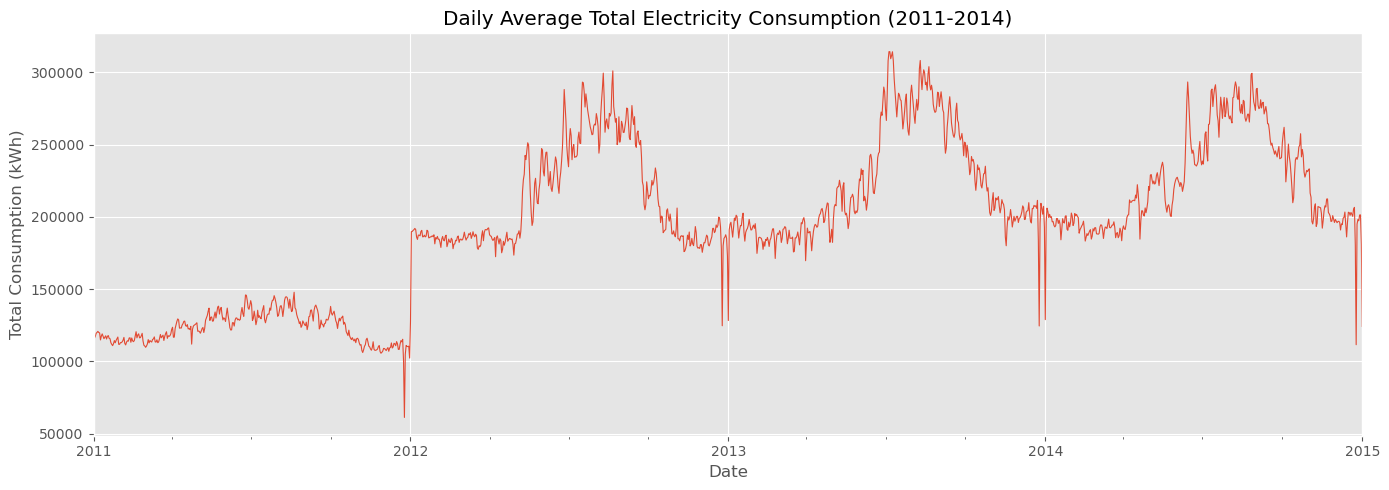

In [47]:
# 7.1 Total consumption over time
fig, ax = plt.subplots(figsize=(14, 5))
df_features['total_consumption'].resample('D').mean().plot(ax=ax, linewidth=0.8)
ax.set_title('Daily Average Total Electricity Consumption (2011-2014)')
ax.set_xlabel('Date')
ax.set_ylabel('Total Consumption (kWh)')
plt.tight_layout()
plt.show()

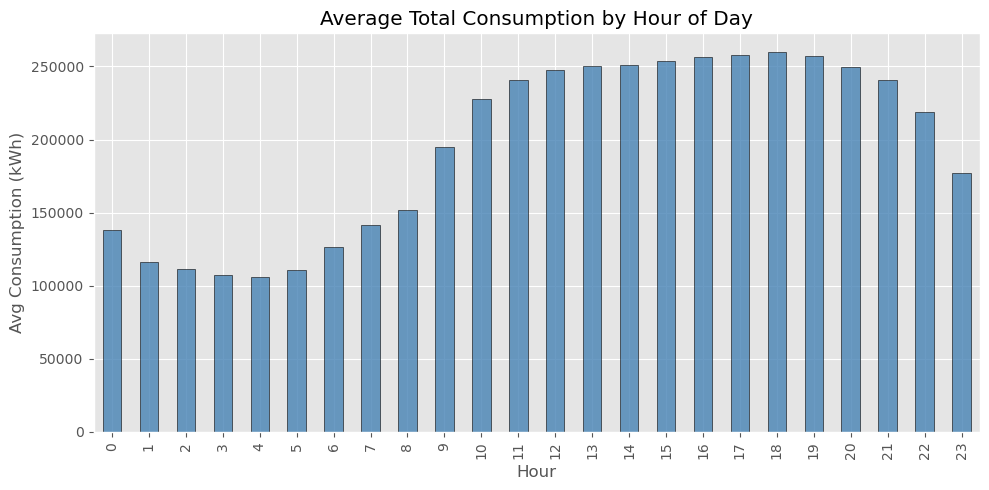

In [48]:
# 7.2 Average consumption by hour of day
fig, ax = plt.subplots(figsize=(10, 5))
hourly_avg = df_features.groupby('hour')['total_consumption'].mean()
hourly_avg.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black', alpha=0.8)
ax.set_title('Average Total Consumption by Hour of Day')
ax.set_xlabel('Hour')
ax.set_ylabel('Avg Consumption (kWh)')
plt.tight_layout()
plt.show()

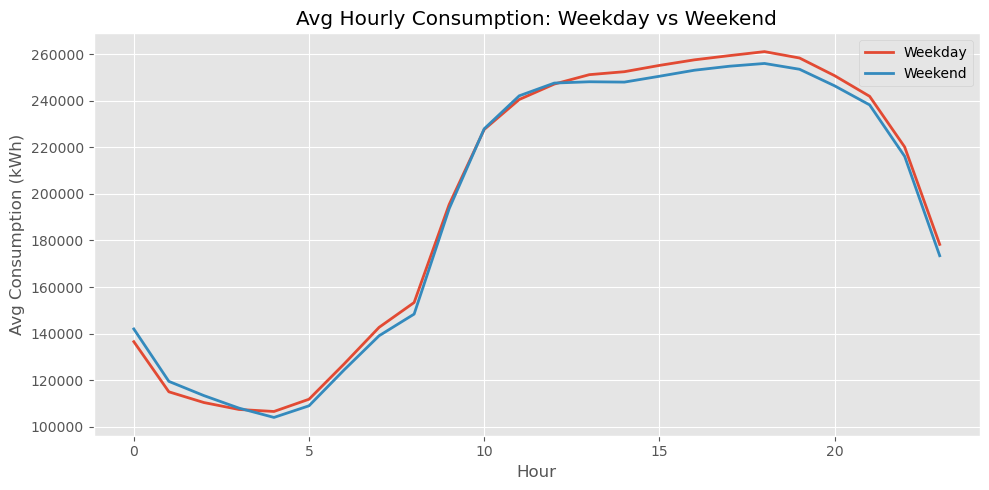

In [49]:
# 7.3 Weekday vs Weekend consumption
fig, ax = plt.subplots(figsize=(10, 5))
for label, group in df_features.groupby('is_weekend'):
    group_hourly = group.groupby('hour')['total_consumption'].mean()
    name = 'Weekend' if label == 1 else 'Weekday'
    group_hourly.plot(ax=ax, label=name, linewidth=2)
ax.set_title('Avg Hourly Consumption: Weekday vs Weekend')
ax.set_xlabel('Hour')
ax.set_ylabel('Avg Consumption (kWh)')
ax.legend()
plt.tight_layout()
plt.show()

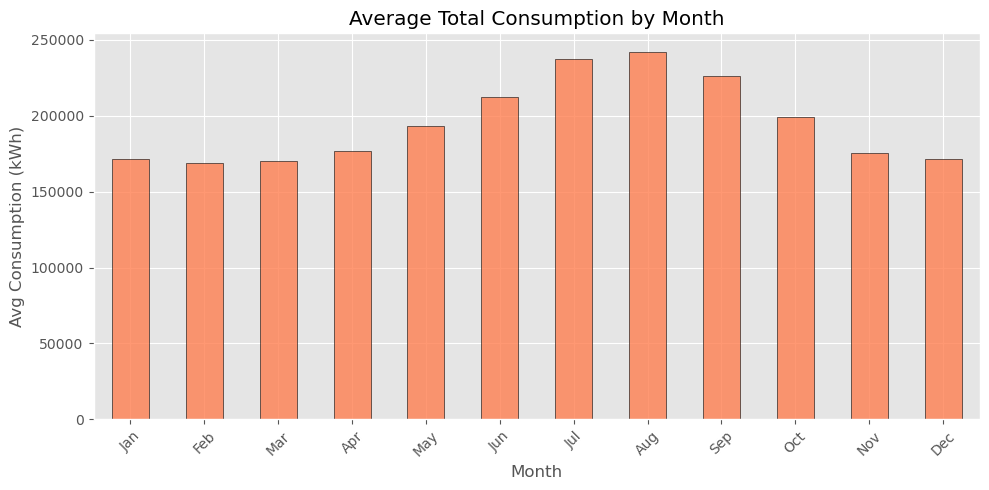

In [50]:
# 7.4 Monthly consumption pattern
fig, ax = plt.subplots(figsize=(10, 5))
monthly_avg = df_features.groupby('month')['total_consumption'].mean()
monthly_avg.plot(kind='bar', ax=ax, color='coral', edgecolor='black', alpha=0.8)
ax.set_title('Average Total Consumption by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Avg Consumption (kWh)')
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
plt.tight_layout()
plt.show()

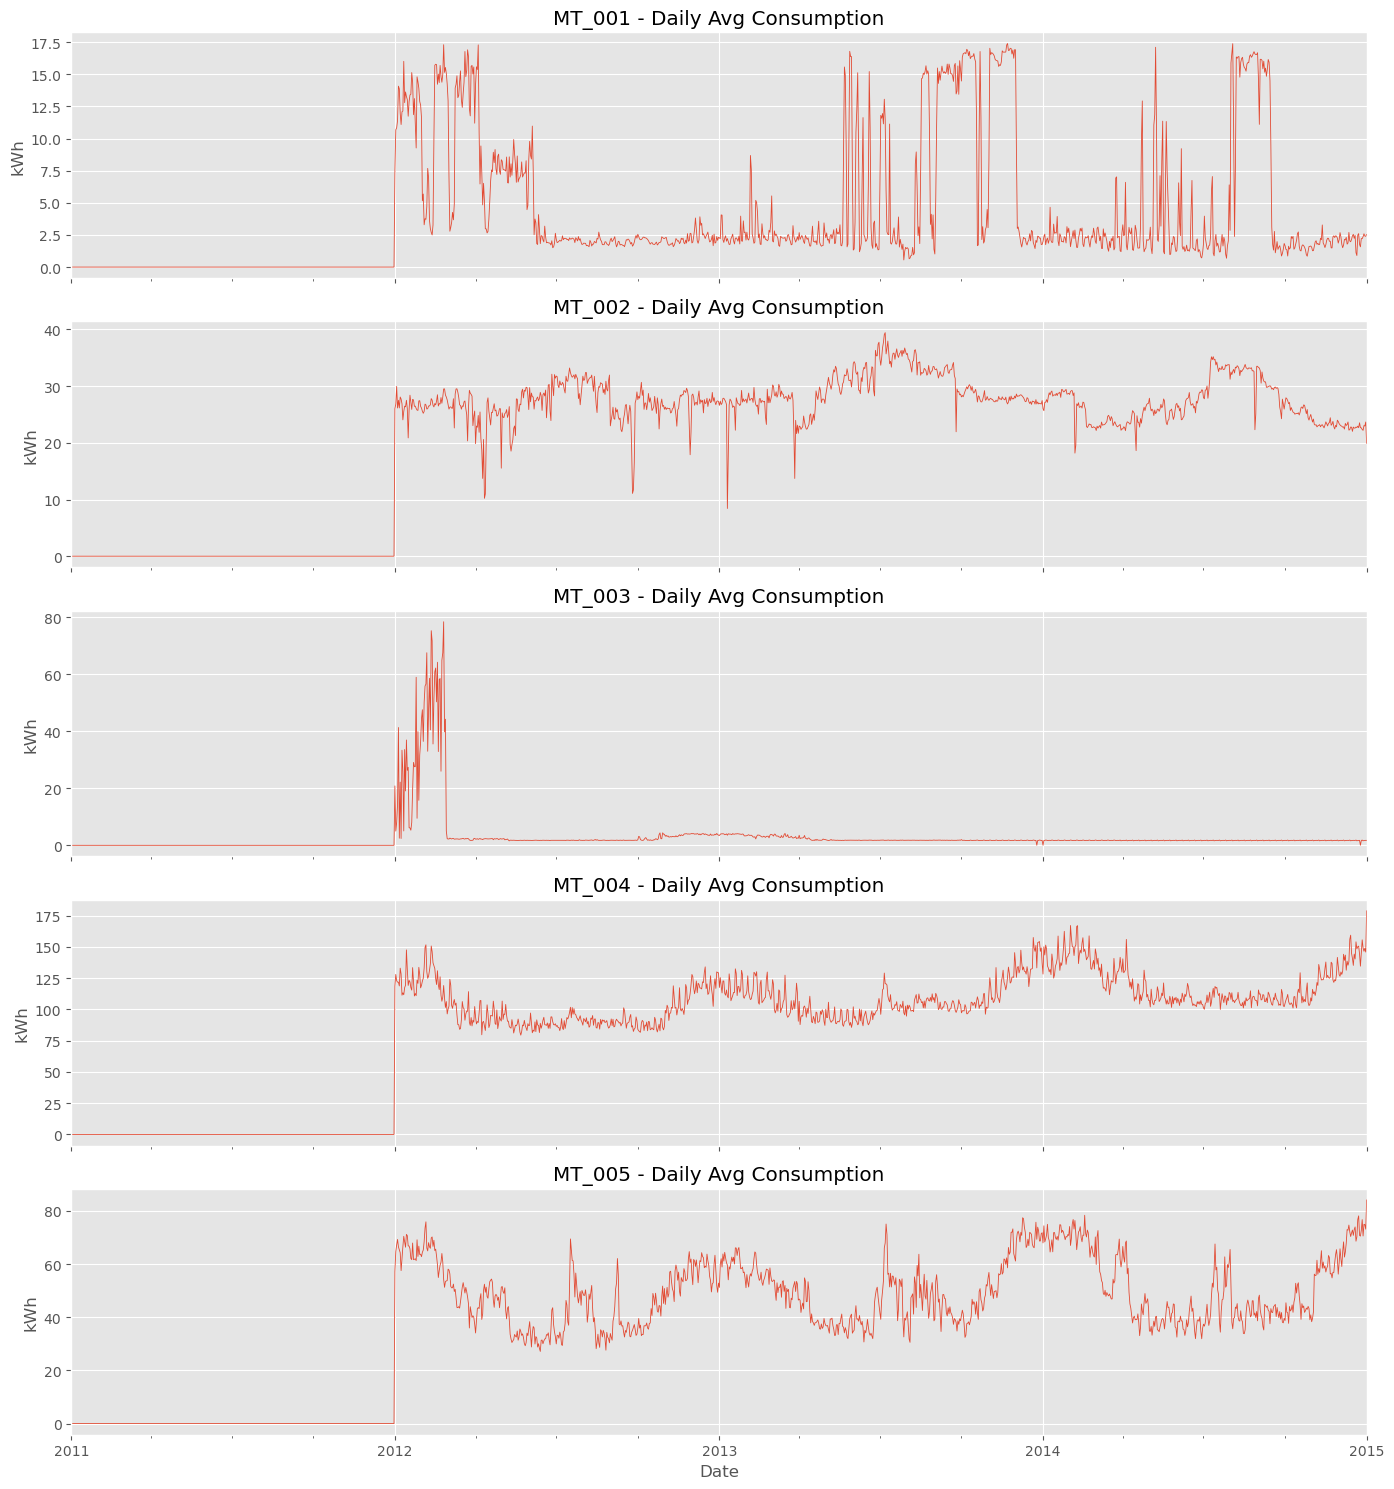

In [51]:
# 7.5 Sample individual meter profiles
sample_meters = [c for c in meter_cols if df_clean[c].sum() > 0][:5]

fig, axes = plt.subplots(len(sample_meters), 1, figsize=(14, 3 * len(sample_meters)), sharex=True)
for ax, meter in zip(axes, sample_meters):
    df_clean[meter].resample('D').mean().plot(ax=ax, linewidth=0.6)
    ax.set_title(f'{meter} - Daily Avg Consumption')
    ax.set_ylabel('kWh')
plt.xlabel('Date')
plt.tight_layout()
plt.show()

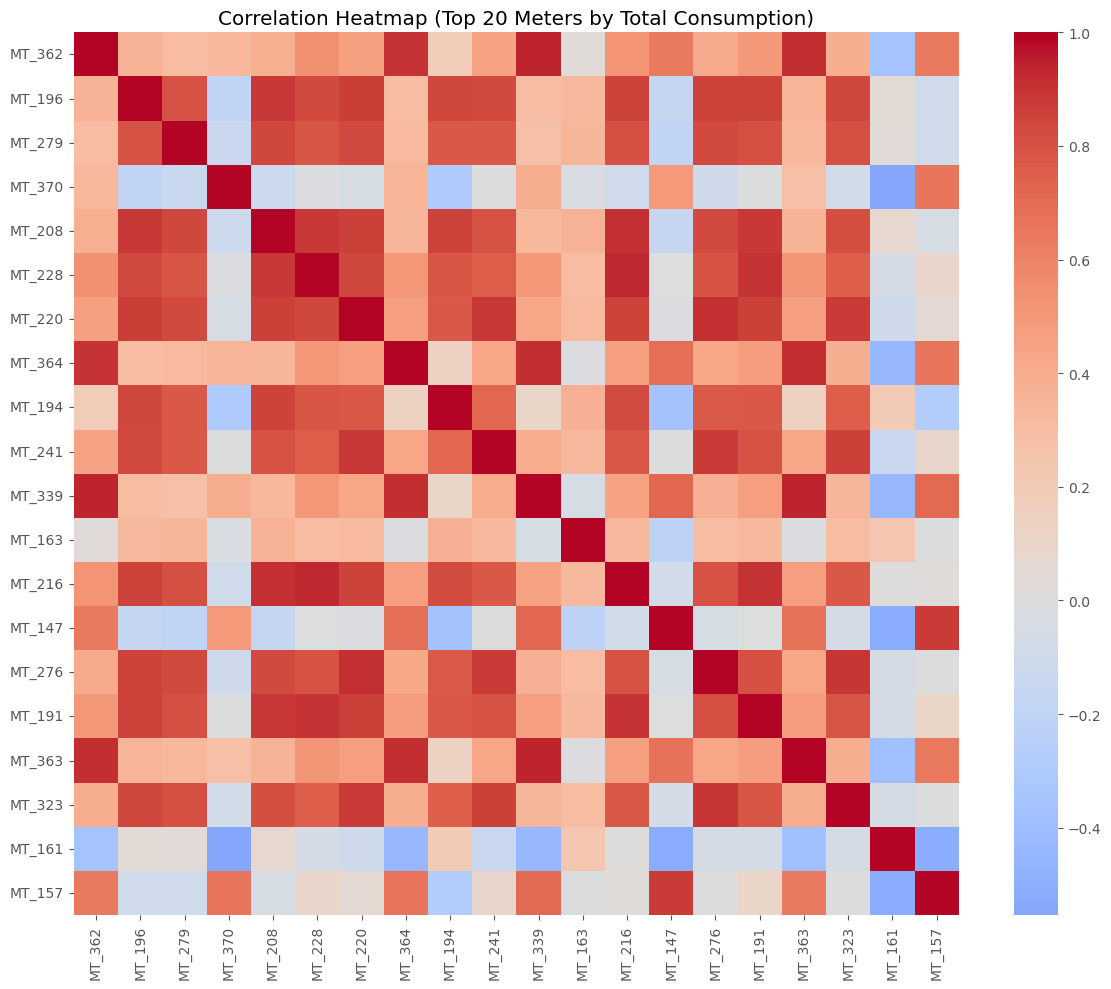

In [52]:
# 7.6 Correlation heatmap (top 20 highest-consumption meters)
top_meters = df_clean[meter_cols].sum().nlargest(20).index.tolist()

fig, ax = plt.subplots(figsize=(12, 10))
corr = df_clean[top_meters].corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap (Top 20 Meters by Total Consumption)')
plt.tight_layout()
plt.show()

## 8. Export to CSV

In [53]:
# 8.1 Save cleaned data (meter columns only) to CSV
OUTPUT_CSV = 'LD2011_2014_cleaned.csv'

print(f'Saving cleaned data to {OUTPUT_CSV}...')
df_clean.to_csv(OUTPUT_CSV)
print(f'Done! Shape: {df_clean.shape}')

Saving cleaned data to LD2011_2014_cleaned.csv...
Done! Shape: (140256, 370)


In [54]:
# 8.2 Save full data with engineered features
FEATURES_CSV = 'LD2011_2014_features.csv'

print(f'Saving feature-engineered data to {FEATURES_CSV}...')
df_features.to_csv(FEATURES_CSV)
print(f'Done! Shape: {df_features.shape}')

Saving feature-engineered data to LD2011_2014_features.csv...
Done! Shape: (140256, 382)


In [55]:
# 8.3 Quick conversion — raw TXT to standard CSV (comma-separated, dot decimal)
RAW_CSV = 'LD2011_2014_raw.csv'

print(f'Converting raw TXT to standard CSV format -> {RAW_CSV}...')
df_raw = pd.read_csv(
    RAW_FILE,
    sep=';',
    decimal=',',
    index_col=0,
    parse_dates=True
)
df_raw.index.name = 'datetime'
df_raw.to_csv(RAW_CSV)
print(f'Done! Shape: {df_raw.shape}')

Converting raw TXT to standard CSV format -> LD2011_2014_raw.csv...
Done! Shape: (140256, 370)


## 9. Summary

### Data Preprocessing Steps Performed:
1. **Loaded** raw semicolon-separated file with European decimal format
2. **Explored** data shape, types, date range, and basic statistics
3. **Checked** for missing values, duplicate timestamps, and time gaps
4. **Analyzed** zero-value and negative-value patterns across meters
5. **Cleaned** data: sorted index, renamed datetime, handled NaNs, clipped negatives
6. **Removed** fully inactive meters (100% zero consumption)
7. **Downcasted** numeric types for memory optimization
8. **Engineered** time-based features (hour, day, month, weekend) and aggregate statistics
9. **Visualized** consumption patterns (daily, hourly, seasonal, weekday vs weekend)
10. **Exported** three CSV files:
    - `LD2011_2014_raw.csv` — direct conversion of raw data to standard CSV
    - `LD2011_2014_cleaned.csv` — cleaned meter data
    - `LD2011_2014_features.csv` — data with engineered features

In [56]:
print('=== Final Summary ===')
print(f'Original shape:          {df.shape}')
print(f'Cleaned shape:           {df_clean.shape}')
print(f'With features shape:     {df_features.shape}')
print(f'Date range:              {df_clean.index.min()} to {df_clean.index.max()}')
print(f'Time resolution:         15 minutes')
print(f'\nFiles saved:')
print(f'  1. {RAW_CSV}')
print(f'  2. {OUTPUT_CSV}')
print(f'  3. {FEATURES_CSV}')

=== Final Summary ===
Original shape:          (140256, 370)
Cleaned shape:           (140256, 370)
With features shape:     (140256, 382)
Date range:              2011-01-01 00:15:00 to 2015-01-01 00:00:00
Time resolution:         15 minutes

Files saved:
  1. LD2011_2014_raw.csv
  2. LD2011_2014_cleaned.csv
  3. LD2011_2014_features.csv
